
# CMI BFRB — IMU + Thermopile + ToF Baseline (LightGBM)
A practical, CPU-friendly baseline that:
- Extracts **sequence-level** features from IMU, rotation (quat), thermopile, and time-of-flight grids
- Merges **demographics**
- Trains a **multiclass LightGBM** model over `gesture` (with a single **non_target** class)
- Reports the **official competition metric** = (Binary F1(target vs non_target) + Macro F1 over gestures incl. non_target) / 2
- Handles **missing sensors** and IMU-only sequences with robust feature logic

> Tip: Put your `train.csv`, `train_demographics.csv` beside this notebook (or set paths below).

In [1]:

# If running locally, uncomment to install
# !pip install lightgbm scikit-learn pandas numpy scipy==1.11.4

import os, gc, math, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb


In [2]:

# ---------------- Config ----------------
DATA_DIR = '.'  # change if needed
TRAIN_CSV = os.path.join(DATA_DIR, 'train.csv')
DEMO_CSV  = os.path.join(DATA_DIR, 'train_demographics.csv')

SEED = 42
N_SPLITS = 5

RANDOM_STATE = SEED
np.random.seed(SEED)


In [3]:

def read_train(train_path=TRAIN_CSV, demo_path=DEMO_CSV):
    dtypes = {
        'row_id': 'int64',
        'sequence_id': 'int64',
        'sequence_counter': 'int32',
        'subject': 'int32',
        'behavior': 'category'
    }
    # IMU + rot columns will be float32; thermopile + tof float32 (with -1 sentinel kept as float)
    imu_cols = [f'acc_{a}' for a in ['x','y','z']]
    rot_cols = [f'rot_{a}' for a in ['w','x','y','z']]
    thm_cols = [f'thm_{i}' for i in range(1,6)]
    tof_cols = [f'tof_{i}_v{j}' for i in range(1,6) for j in range(64)]
    
    usecols = ['row_id','sequence_id','sequence_type','sequence_counter','subject','gesture','orientation','behavior'] + imu_cols + rot_cols + thm_cols + tof_cols
    # Train-only columns `sequence_type`, `gesture`, `orientation` may not exist in test; guard for train only here
    df = pd.read_csv(train_path, usecols=usecols, dtype={c:'float32' for c in imu_cols+rot_cols+thm_cols+tof_cols}, low_memory=True)
    for c in ['sequence_type','gesture','orientation']:
        if c in df.columns:
            df[c] = df[c].astype('category')
    demo = pd.read_csv(demo_path)
    return df, demo, imu_cols, rot_cols, thm_cols, tof_cols


In [4]:

def _basic_stats(arr):
    # arr is 1D np array with nan allowed
    a = arr[np.isfinite(arr)]
    if a.size == 0:
        return {
            'mean': np.nan, 'std': np.nan, 'min': np.nan, 'max': np.nan, 'median': np.nan,
            'p10': np.nan, 'p90': np.nan, 'iqr': np.nan, 'rms': np.nan
        }
    q10, q90 = np.percentile(a, [10, 90])
    return {
        'mean': np.mean(a), 'std': np.std(a), 'min': np.min(a), 'max': np.max(a), 'median': np.median(a),
        'p10': q10, 'p90': q90, 'iqr': q90 - q10, 'rms': math.sqrt(np.mean(a*a))
    }

def _phase_fracs(beh_series):
    # behavior has Transition / Pause / Gesture strings
    n = len(beh_series)
    if n == 0:
        return {'frac_transition': np.nan, 'frac_pause': np.nan, 'frac_gesture': np.nan}
    t = (beh_series == 'Transition').sum() / n
    p = (beh_series == 'Pause').sum() / n
    g = (beh_series == 'Gesture').sum() / n
    return {'frac_transition': t, 'frac_pause': p, 'frac_gesture': g}

def _quat_angular_velocity(rot_wxyz):
    # approximate angular velocity magnitude between consecutive quaternion samples
    # rot_wxyz: (N,4)
    q = rot_wxyz.astype('float64')
    if len(q) < 2:
        return np.array([np.nan])
    # delta quaternion magnitude via dot products (cos(theta/2)=|<q1,q2>|)
    dots = np.einsum('ij,ij->i', q[:-1], q[1:])
    dots = np.clip(dots, -1.0, 1.0)
    theta = 2.0 * np.arccos(np.abs(dots))  # angle between orientations
    return theta  # not divided by dt (unknown), relative magnitude only

def features_for_sequence(g):
    # g: DataFrame for a single sequence_id
    feats = {}
    # Phase fractions
    feats.update(_phase_fracs(g['behavior']))
    
    # IMU stats
    for col in [c for c in g.columns if c.startswith('acc_')]:
        s = _basic_stats(g[col].values)
        for k,v in s.items(): feats[f'{col}_{k}'] = v
    # Resultant acceleration
    if set(['acc_x','acc_y','acc_z']).issubset(g.columns):
        res = np.sqrt((g['acc_x']**2 + g['acc_y']**2 + g['acc_z']**2).values)
        s = _basic_stats(res); feats.update({f'acc_res_{k}': v for k,v in s.items()})
    
    # Rotation (quat) angular change stats
    rot_cols = [c for c in g.columns if c.startswith('rot_')]
    if len(rot_cols) == 4:
        ang = _quat_angular_velocity(g[rot_cols].values)
        s = _basic_stats(ang); feats.update({f'rot_ang_{k}': v for k,v in s.items()})
    
    # Thermopile
    thm_cols = [c for c in g.columns if c.startswith('thm_')]
    if thm_cols:
        thm = g[thm_cols].values.astype('float32')
        # Per-sensor stats, then global
        thm_valid = np.isfinite(thm)
        feats['thm_has_data'] = float(np.any(thm_valid))
        t = thm[thm_valid]
        if t.size > 0:
            s = _basic_stats(t)
            feats.update({f'thm_{k}': v for k,v in s.items()})
        else:
            for k in ['mean','std','min','max','median','p10','p90','iqr','rms']:
                feats[f'thm_{k}'] = np.nan
    
    # Time-of-Flight: flatten all 5x(8x8) pixels
    tof_cols = [c for c in g.columns if c.startswith('tof_')]
    if tof_cols:
        tof = g[tof_cols].values.astype('float32')
        # valid where value >= 0 (dataset uses -1 for no return)
        valid = tof >= 0
        feats['tof_has_data'] = float(valid.any())
        valid_vals = tof[valid]
        feats['tof_valid_ratio'] = float(valid.sum()) / float(np.prod(tof.shape)) if tof.size else np.nan
        if valid_vals.size > 0:
            s = _basic_stats(valid_vals)
            feats.update({f'tof_{k}': v for k,v in s.items()})
            feats['tof_min_overall'] = float(np.min(valid_vals))
        else:
            for k in ['mean','std','min','max','median','p10','p90','iqr','rms']:
                feats[f'tof_{k}'] = np.nan
            feats['tof_min_overall'] = np.nan
    return feats


In [5]:
def build_features(df, demo):
    """
    Build one feature row per sequence_id, then merge minimal metadata
    and demographics. Robust to string/non-numeric subject IDs.

    Returns:
        DataFrame with columns:
          - sequence_id
          - engineered features (acc/rot/thm/tof/phase)
          - subject, sequence_type, gesture, orientation (if present)
          - demographics (if demo provided)
          - subject_group_id (int codes for GroupKFold)
    """
    import pandas as pd
    import numpy as np

    # Defensive copy & dtypes
    df = df.copy()
    # Keep IDs as strings to avoid int casting errors (e.g., 'SUBJ_059520')
    if 'sequence_id' in df.columns:
        df['sequence_id'] = df['sequence_id'].astype(str)
    if 'subject' in df.columns:
        df['subject'] = df['subject'].astype(str)

    # Minimal meta to carry forward
    base_cols = ['sequence_id', 'subject', 'sequence_type', 'gesture', 'orientation']
    keep_cols = [c for c in base_cols if c in df.columns]

    # One row of meta per sequence_id
    if keep_cols:
        meta = (
            df[keep_cols]
            .drop_duplicates(subset=['sequence_id'])
            .set_index('sequence_id')
        )
    else:
        # In rare cases where none exist
        meta = pd.DataFrame(index=df['sequence_id'].drop_duplicates()).iloc[0:0]

    # ---- Aggregate per sequence_id ----
    feats = []
    # groupby preserves order with sort=False
    for seq_id, g in df.groupby('sequence_id', sort=False):
        f = {'sequence_id': seq_id}
        f.update(features_for_sequence(g))  # your existing per-sequence featurizer
        feats.append(f)

    X = pd.DataFrame(feats).set_index('sequence_id')

    # ---- Join meta ----
    X = X.join(meta, how='left')

    # ---- Join demographics (if provided) ----
    if demo is not None and isinstance(demo, pd.DataFrame) and 'subject' in X.columns:
        demo_df = demo.copy()
        # Ensure same key dtype
        if 'subject' in demo_df.columns:
            demo_df['subject'] = demo_df['subject'].astype(str)
            demo_df = demo_df.set_index('subject')
            X = X.join(demo_df, on='subject', how='left', rsuffix='_demo')

    # ---- Add numeric group id for CV (safe for alphanumeric subjects) ----
    if 'subject' in X.columns:
        subj = X['subject'].fillna('UNKNOWN_SUBJ').astype(str)
        X['subject_group_id'] = pd.factorize(subj)[0].astype('int32')
    else:
        # Fallback: group by sequence_id (less ideal, but safe)
        X['subject_group_id'] = pd.factorize(X.index.astype(str))[0].astype('int32')

    return X.reset_index()




In [6]:

def official_metric(y_true_gesture, y_pred_gesture, non_target_label='non_target'):
    # Macro F1 over gestures (including a single non_target class)
    macro_f1 = f1_score(y_true_gesture, y_pred_gesture, average='macro')
    
    # Binary target vs non_target
    def to_bin(y):
        return np.array([0 if v == non_target_label else 1 for v in y])
    bin_true = to_bin(y_true_gesture)
    bin_pred = to_bin(y_pred_gesture)
    bin_f1 = f1_score(bin_true, bin_pred, average='binary')
    return (macro_f1 + bin_f1)/2.0, macro_f1, bin_f1


In [7]:
def train_lgbm(X):
    """
    Train a multiclass LightGBM with GroupKFold.
    Groups are taken from:
      1) subject_group_id (preferred, created in build_features), else
      2) factorized string subject, else
      3) factorized sequence_id (fallback).
    """
    import gc
    import numpy as np
    import pandas as pd
    from sklearn.model_selection import GroupKFold
    from sklearn.metrics import f1_score
    from sklearn.preprocessing import LabelEncoder
    import lightgbm as lgb

    assert 'gesture' in X.columns, "Train data must contain 'gesture'"

    # Labels
    y = X['gesture'].astype(str).values

    # Choose groups safely (no int casting of strings)
    if 'subject_group_id' in X.columns:
        groups = X['subject_group_id'].astype(int).values
    elif 'subject' in X.columns:
        groups = pd.factorize(X['subject'].fillna('UNKNOWN_SUBJ').astype(str))[0]
    else:
        groups = pd.factorize(X['sequence_id'].astype(str))[0]

    # Build feature matrix (exclude IDs/labels/metadata)
    drop_cols = ['gesture', 'sequence_type', 'orientation',
                 'sequence_id', 'subject', 'subject_group_id']
    feats = [c for c in X.columns if c not in drop_cols]

    Xf = X[feats].copy()
    Xf = Xf.replace([np.inf, -np.inf], np.nan)
    # LightGBM can handle NaN, but we’ll be conservative
    Xf = Xf.fillna(Xf.median(numeric_only=True))

    # Encode labels
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    # Cross-validation (grouped by subject)
    gkf = GroupKFold(n_splits=5)
    oof_pred = np.zeros((len(Xf), len(le.classes_)), dtype='float32')
    models = []

    for fold, (tr, va) in enumerate(gkf.split(Xf, y_enc, groups)):
        X_tr, X_va = Xf.iloc[tr], Xf.iloc[va]
        y_tr, y_va = y_enc[tr], y_enc[va]

        train_set = lgb.Dataset(X_tr, label=y_tr)
        valid_set = lgb.Dataset(X_va, label=y_va)

        params = dict(
            objective='multiclass',
            num_class=len(le.classes_),
            # Use a metric so early stopping can monitor validation:
            metric='multi_logloss',
            learning_rate=0.05,
            num_leaves=64,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            min_data_in_leaf=40,
            feature_fraction=0.8,
            seed=42 + fold,
            verbosity=-1
        )

        model = lgb.train(
            params,
            train_set,
            valid_sets=[valid_set],
            num_boost_round=3000,
            callbacks=[
                lgb.early_stopping(stopping_rounds=100),
                lgb.log_evaluation(period=100),  # print every 100 iters; remove to silence
            ],
        )
        models.append(model)
        oof_pred[va] = model.predict(X_va, num_iteration=model.best_iteration)
        gc.collect()

    # Official metric: average of macro-F1(gestures incl. non_target) and binary F1(target vs non_target)
    def official_metric(y_true_gesture, y_pred_gesture, non_target_label='non_target'):
        macro_f1 = f1_score(y_true_gesture, y_pred_gesture, average='macro')
        to_bin = lambda y: np.array([0 if v == non_target_label else 1 for v in y])
        bin_f1 = f1_score(to_bin(y_true_gesture), to_bin(y_pred_gesture), average='binary')
        return (macro_f1 + bin_f1) / 2.0, macro_f1, bin_f1

    y_oof_lbl = le.inverse_transform(oof_pred.argmax(1))
    official, macro_f1, bin_f1 = official_metric(y, y_oof_lbl, non_target_label='non_target')
    print(f'OOF — Official: {official:.4f} | MacroF1: {macro_f1:.4f} | BinF1: {bin_f1:.4f}')

    return {
        'models': models,
        'features': feats,
        'label_encoder': le,
        'metric_oof': float(official),
        'macro_f1_oof': float(macro_f1),
        'bin_f1_oof': float(bin_f1)
    }



In [8]:

if os.path.exists(TRAIN_CSV) and os.path.exists(DEMO_CSV):
    df, demo, imu_cols, rot_cols, thm_cols, tof_cols = read_train()
    print('Loaded:', df.shape, 'Demo:', demo.shape)
    X = build_features(df, demo)
    print('Feature table:', X.shape)
    info = train_lgbm(X)
else:
    print("Place 'train.csv' and 'train_demographics.csv' next to this notebook and re-run.")


Loaded: (574945, 340) Demo: (81, 8)
Feature table: (8151, 83)
Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 1.37617
Early stopping, best iteration is:
[71]	valid_0's multi_logloss: 1.34882
Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 1.38364
Early stopping, best iteration is:
[81]	valid_0's multi_logloss: 1.37514
Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 1.28968
Early stopping, best iteration is:
[88]	valid_0's multi_logloss: 1.28587
Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 1.36182
Early stopping, best iteration is:
[81]	valid_0's multi_logloss: 1.34705
Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 1.22192
Early stopping, best iteration is:
[94]	valid_0's multi_logloss: 1.22007
OOF — Official: 0.7841 | MacroF1: 0.5681 | BinF1: 1.0000



## Inference (for the Kaggle evaluation API)
Below is a helper that turns one **served test sequence** into features and returns model predictions.


In [9]:

def predict_sequence(models, feats, le, seq_df, demo_df):
    # Build a one-row feature frame like training
    Xs = build_features(seq_df, demo_df)
    drop_cols = ['gesture','sequence_type','orientation','sequence_id','subject']
    feat_cols = [c for c in Xs.columns if c not in drop_cols]
    Xf = Xs[feat_cols].copy()
    Xf = Xf.replace([np.inf, -np.inf], np.nan)
    Xf = Xf.fillna(Xf.median(numeric_only=True))
    # align to training features
    for c in feats:
        if c not in Xf.columns:
            Xf[c] = np.nan
    Xf = Xf[feats].fillna(0)
    
    # average softmax across models
    pred = np.zeros((len(Xf), len(le.classes_)), dtype='float32')
    for m in models:
        pred += m.predict(Xf, num_iteration=m.best_iteration)
    pred /= len(models)
    cls = pred.argmax(1)
    return le.inverse_transform(cls)[0], pred[0]


Loaded: (574945, 341)


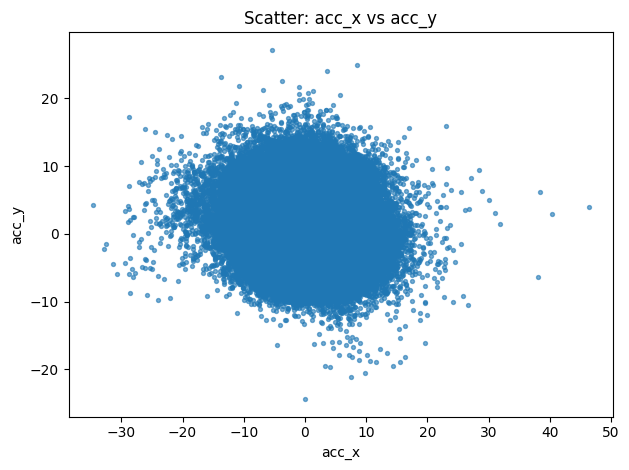

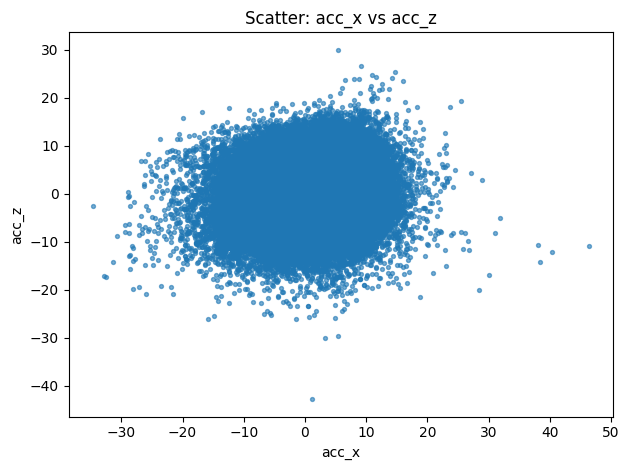

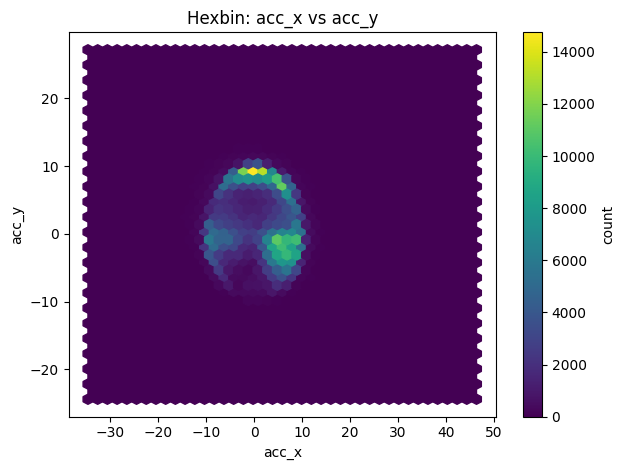

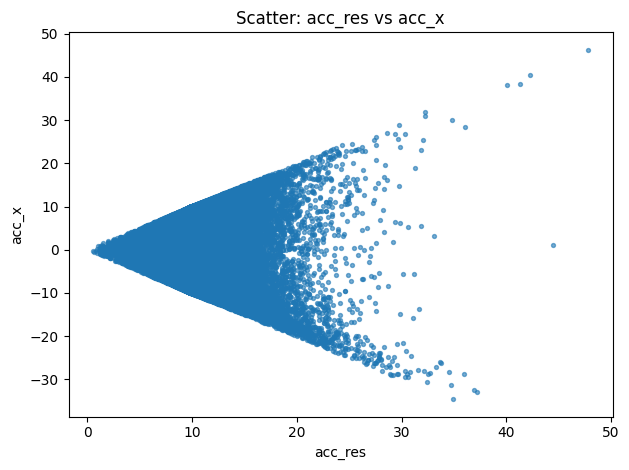

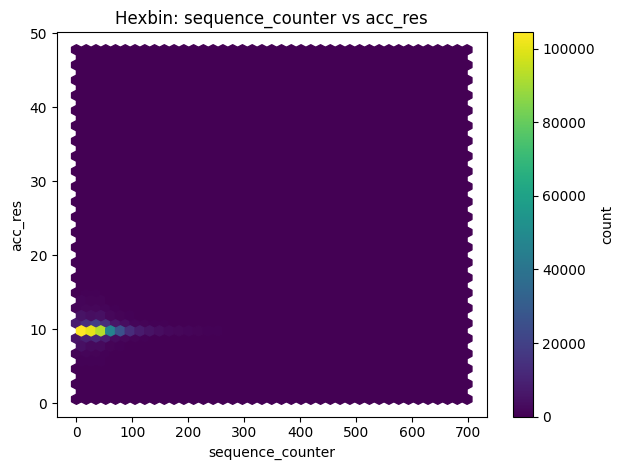

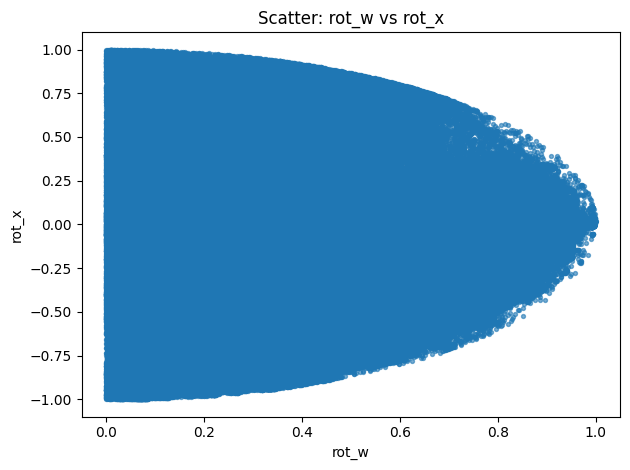

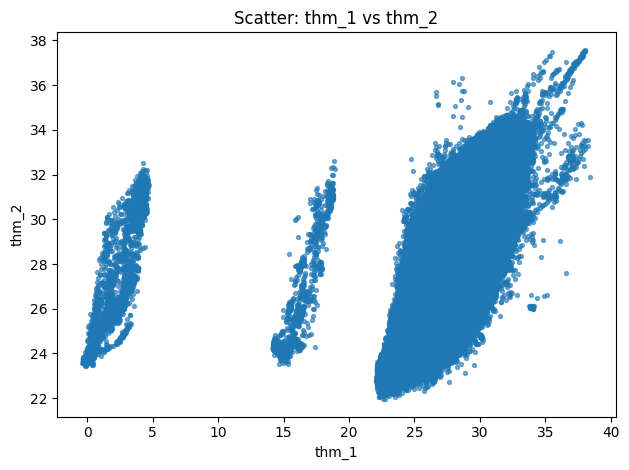

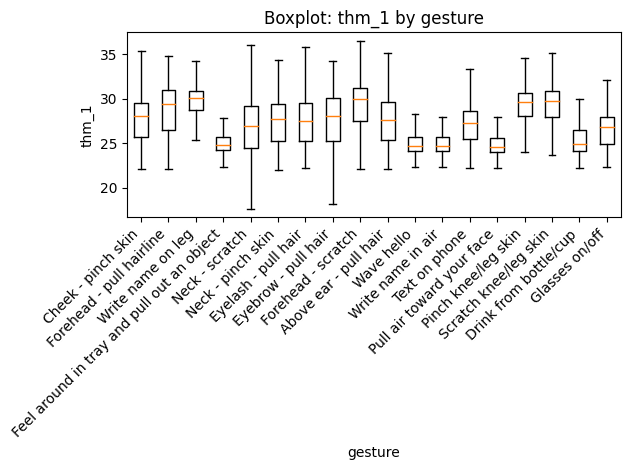

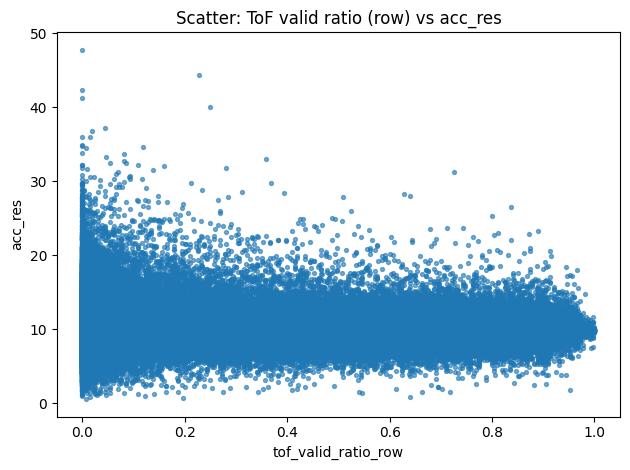

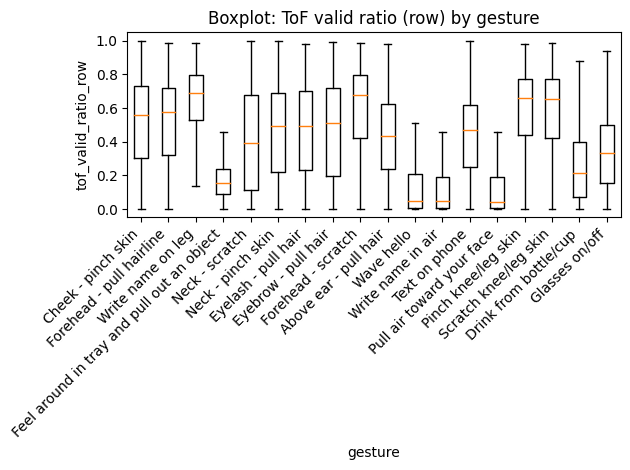

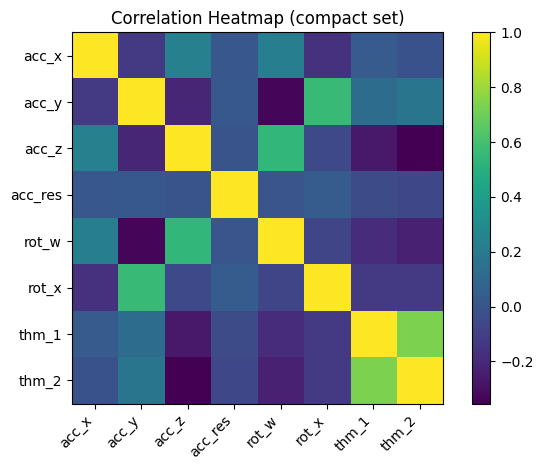

In [10]:
# ============================
# Relational Charts (Matplotlib-only)
# ============================
# Usage:
#   CSV_PATH = "train.csv"   # or "train.csv" / "test.csv"
#   Run the cell to produce a set of relational charts.
#
# Notes:
#   - No seaborn.
#   - Each chart is its own figure (no subplots).
#   - No explicit colors set.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
CSV_PATH = "train.csv"   # change to your file, e.g. "train.csv"
GROUP_COL_CANDIDATES = ["gesture", "sequence_type", "orientation", "subject", "adult_child", "sex"]

# ---------- LOAD ----------
df = pd.read_csv(CSV_PATH, low_memory=True)
print("Loaded:", df.shape)

# ---------- COLUMN SETS ----------
acc_cols = [c for c in df.columns if c.startswith("acc_")]
rot_cols = [c for c in df.columns if c.startswith("rot_")]
thm_cols = [c for c in df.columns if c.startswith("thm_")]
tof_cols = [c for c in df.columns if c.startswith("tof_")]

# Try to pick a grouping column if available (for boxplots)
group_col = next((c for c in GROUP_COL_CANDIDATES if c in df.columns), None)

# ---------- HELPERS ----------
def safe_series(x):
    """Return a clean numeric series (coerce to numeric, drop NaN/inf for plotting)."""
    s = pd.to_numeric(x, errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan)
    return s

def scatter_chart(df, x_col, y_col, title):
    x = safe_series(df[x_col])
    y = safe_series(df[y_col])
    m = np.isfinite(x) & np.isfinite(y)
    plt.figure()
    plt.scatter(x[m], y[m], s=8, alpha=0.6)
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

def hexbin_chart(df, x_col, y_col, title, gridsize=40):
    x = safe_series(df[x_col])
    y = safe_series(df[y_col])
    m = np.isfinite(x) & np.isfinite(y)
    plt.figure()
    plt.hexbin(x[m], y[m], gridsize=gridsize)
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    cb = plt.colorbar()
    cb.set_label('count')
    plt.tight_layout()
    plt.show()

def boxplot_by(df, value_col, by_col, title):
    if by_col not in df.columns:
        print(f"[skip] '{by_col}' not found for boxplot.")
        return
    s = safe_series(df[value_col])
    g = df[by_col].astype(str)
    data = [s[g == cat].dropna() for cat in g.dropna().unique()]
    labels = list(g.dropna().unique())
    if len(labels) < 2:
        print(f"[skip] Not enough groups in '{by_col}' for boxplot.")
        return
    plt.figure()
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.title(title)
    plt.xlabel(by_col)
    plt.ylabel(value_col)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def corr_heatmap(df, cols, title):
    # Build correlation only on finite numeric values
    sub = df[cols].apply(pd.to_numeric, errors="coerce")
    corr = sub.corr()
    plt.figure()
    plt.imshow(corr, interpolation='nearest')
    plt.title(title)
    plt.xticks(range(len(cols)), cols, rotation=45, ha='right')
    plt.yticks(range(len(cols)), cols)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# ---------- DERIVED METRICS (OPTIONAL, USEFUL RELATIONS) ----------
# Resultant acceleration if acc_x/y/z present
if set(["acc_x","acc_y","acc_z"]).issubset(df.columns):
    res = np.sqrt(safe_series(df["acc_x"])**2 + safe_series(df["acc_y"])**2 + safe_series(df["acc_z"])**2)
    df["acc_res"] = res

# ToF valid ratio per row (fraction of pixels >= 0) if ToF columns exist
if tof_cols:
    tof_block = df[tof_cols].apply(pd.to_numeric, errors="coerce")
    df["tof_valid_ratio_row"] = (tof_block >= 0).mean(axis=1)

# ---------- 1) RELATIONSHIPS WITH ACCELEROMETER ----------
# Scatter acc_x vs acc_y
if "acc_x" in acc_cols and "acc_y" in acc_cols:
    scatter_chart(df, "acc_x", "acc_y", "Scatter: acc_x vs acc_y")

# Scatter acc_x vs acc_z
if "acc_x" in acc_cols and "acc_z" in acc_cols:
    scatter_chart(df, "acc_x", "acc_z", "Scatter: acc_x vs acc_z")

# Hexbin acc_x vs acc_y (density view)
if "acc_x" in acc_cols and "acc_y" in acc_cols:
    hexbin_chart(df, "acc_x", "acc_y", "Hexbin: acc_x vs acc_y")

# ---------- 2) RELATIONSHIPS WITH RESULTANT ACCEL (if computed) ----------
if "acc_res" in df.columns and "acc_x" in acc_cols:
    scatter_chart(df, "acc_res", "acc_x", "Scatter: acc_res vs acc_x")

# If sequence_counter exists, see motion vs time (hexbin)
if "acc_res" in df.columns and "sequence_counter" in df.columns:
    hexbin_chart(df, "sequence_counter", "acc_res", "Hexbin: sequence_counter vs acc_res")

# ---------- 3) ROTATION QUATERNION RELATIONS ----------
if len(rot_cols) >= 2:
    # Pick first two rot columns deterministically
    rc = rot_cols[:2]
    scatter_chart(df, rc[0], rc[1], f"Scatter: {rc[0]} vs {rc[1]}")

# ---------- 4) THERMOPILE RELATIONS ----------
if len(thm_cols) >= 2:
    scatter_chart(df, thm_cols[0], thm_cols[1], f"Scatter: {thm_cols[0]} vs {thm_cols[1]}")

# Boxplot of a thermopile vs group (if group col exists)
if len(thm_cols) >= 1 and group_col:
    boxplot_by(df, thm_cols[0], group_col, f"Boxplot: {thm_cols[0]} by {group_col}")

# ---------- 5) ToF RELATIONS ----------
# If we computed row-wise ToF valid ratio, relate it to motion
if "tof_valid_ratio_row" in df.columns and "acc_res" in df.columns:
    scatter_chart(df, "tof_valid_ratio_row", "acc_res", "Scatter: ToF valid ratio (row) vs acc_res")

# If we have a label/group, show how ToF valid ratio differs by group
if "tof_valid_ratio_row" in df.columns and group_col:
    boxplot_by(df, "tof_valid_ratio_row", group_col, f"Boxplot: ToF valid ratio (row) by {group_col}")

# ---------- 6) CORRELATION HEATMAP (COMPACT) ----------
# To avoid massive plots, focus on a compact set of informative numeric columns
corr_cols = []
corr_cols += [c for c in ["acc_x","acc_y","acc_z","acc_res"] if c in df.columns]
corr_cols += rot_cols[:2] if len(rot_cols) >= 2 else rot_cols  # up to 2 rot cols
corr_cols += thm_cols[:2] if len(thm_cols) >= 2 else thm_cols  # up to 2 thm cols

# Only make heatmap if we have at least 3 cols
corr_cols = list(dict.fromkeys([c for c in corr_cols if c in df.columns]))  # dedup & ensure presence
if len(corr_cols) >= 3:
    corr_heatmap(df, corr_cols, "Correlation Heatmap (compact set)")
else:
    print("[info] Not enough columns for correlation heatmap.")


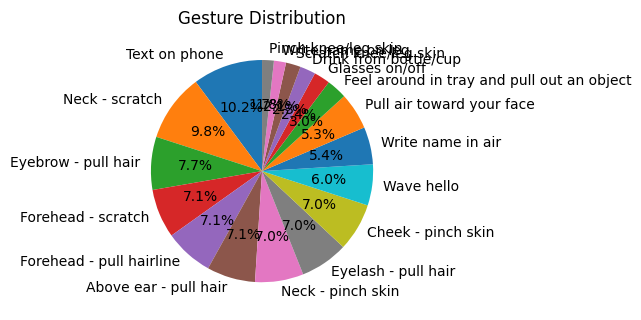

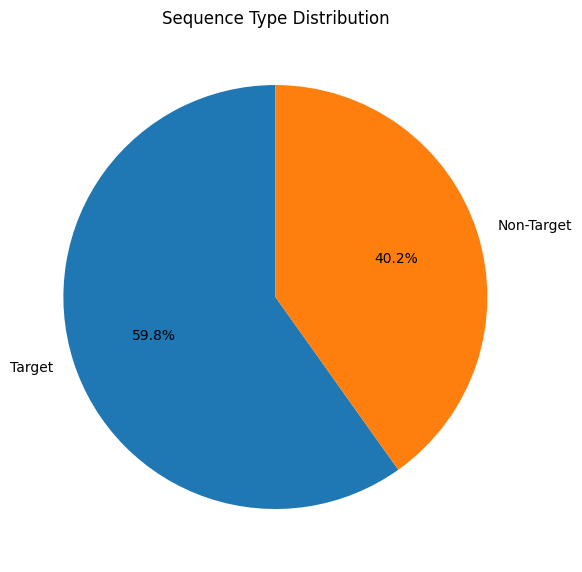

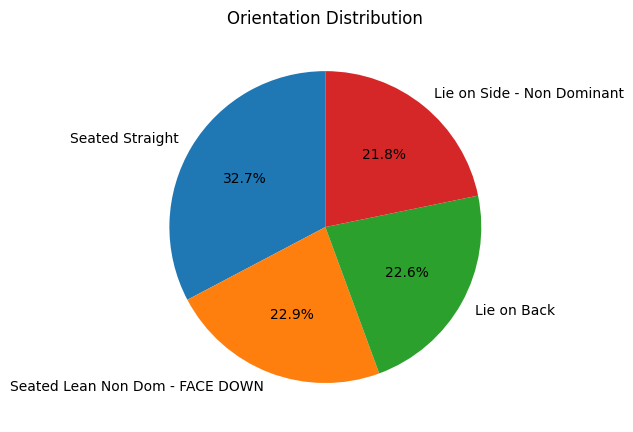

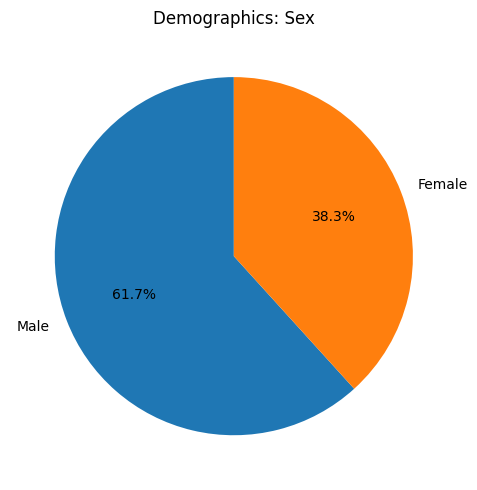

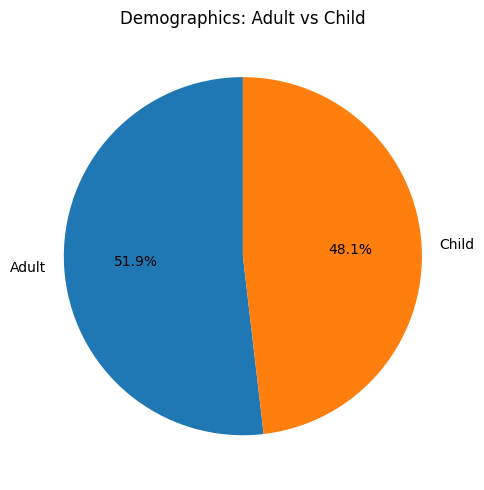

In [11]:
# =======================
# Pie Chart Examples
# =======================

import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "train.csv"   # change to train.csv / test.csv as needed
df = pd.read_csv(CSV_PATH, low_memory=True)

# --- Example 1: Gesture distribution (if present) ---
if "gesture" in df.columns:
    counts = df["gesture"].astype(str).value_counts()
    plt.figure(figsize=(6,6))
    counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
    plt.title("Gesture Distribution")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("[INFO] 'gesture' column not found, skipping gesture pie chart.")

# --- Example 2: Sequence_type distribution (if present) ---
if "sequence_type" in df.columns:
    counts = df["sequence_type"].astype(str).value_counts()
    plt.figure(figsize=(6,6))
    counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
    plt.title("Sequence Type Distribution")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

# --- Example 3: Orientation distribution (if present) ---
if "orientation" in df.columns:
    counts = df["orientation"].astype(str).value_counts()
    plt.figure(figsize=(6,6))
    counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
    plt.title("Orientation Distribution")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

# --- Example 4: Demographics pies (if demo.csv is loaded separately) ---
# For test_demographics.csv or train_demographics.csv
try:
    demo = pd.read_csv("train_demographics.csv")  # change path as needed
    if "sex" in demo.columns:
        counts = demo["sex"].map({0:"Female",1:"Male"}).value_counts()
        plt.figure(figsize=(5,5))
        counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
        plt.title("Demographics: Sex")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()
    if "adult_child" in demo.columns:
        counts = demo["adult_child"].map({0:"Child",1:"Adult"}).value_counts()
        plt.figure(figsize=(5,5))
        counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
        plt.title("Demographics: Adult vs Child")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()
except FileNotFoundError:
    print("[INFO] No demographics file found, skipping demo pies.")


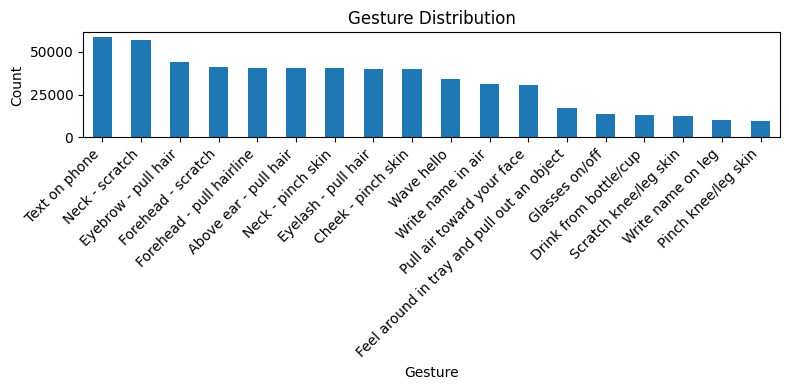

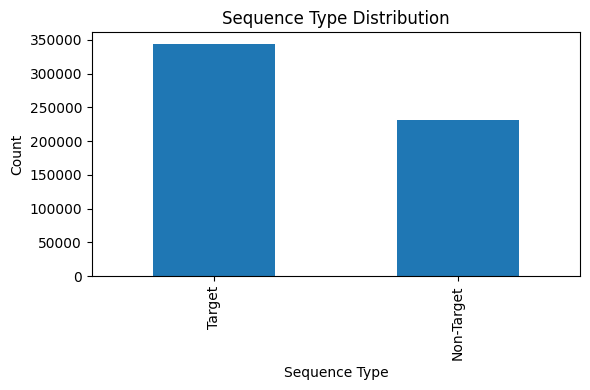

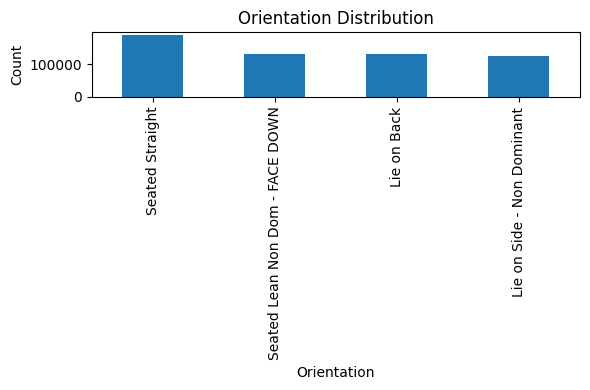

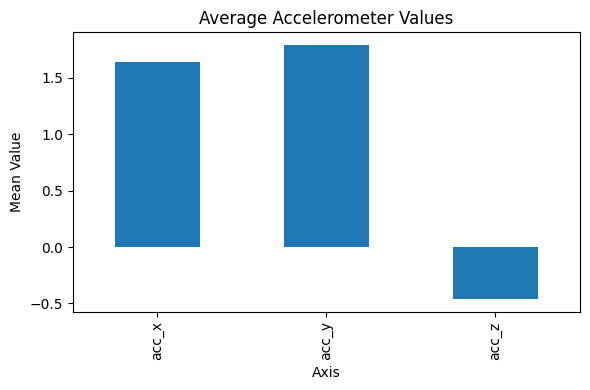

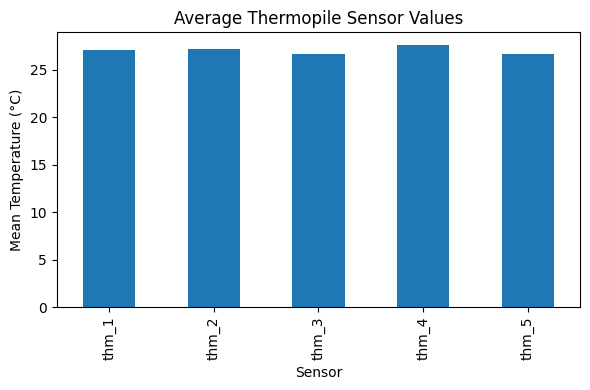

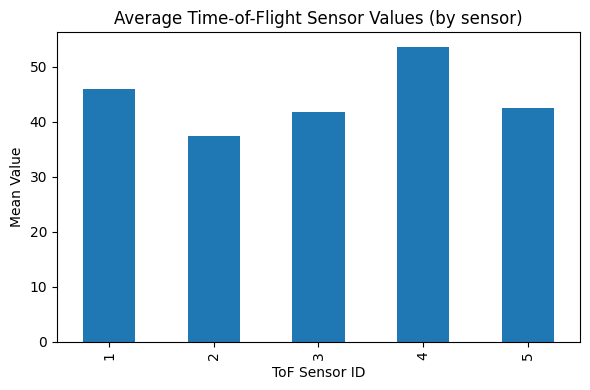

In [12]:
# ================================
# Bar Chart Analysis (Matplotlib only)
# ================================
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV
file_path = "train.csv"   # change if needed
df = pd.read_csv(file_path)

# --- 1) Gesture distribution ---
if "gesture" in df.columns:
    gesture_counts = df["gesture"].astype(str).value_counts()
    plt.figure(figsize=(8,4))
    gesture_counts.plot(kind="bar")
    plt.title("Gesture Distribution")
    plt.xlabel("Gesture")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# --- 2) Sequence type distribution ---
if "sequence_type" in df.columns:
    seq_counts = df["sequence_type"].astype(str).value_counts()
    plt.figure(figsize=(6,4))
    seq_counts.plot(kind="bar")
    plt.title("Sequence Type Distribution")
    plt.xlabel("Sequence Type")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# --- 3) Orientation distribution ---
if "orientation" in df.columns:
    ori_counts = df["orientation"].astype(str).value_counts()
    plt.figure(figsize=(6,4))
    ori_counts.plot(kind="bar")
    plt.title("Orientation Distribution")
    plt.xlabel("Orientation")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# --- 4) Average accelerometer values ---
acc_cols = [c for c in df.columns if c.startswith("acc_")]
if acc_cols:
    acc_means = df[acc_cols].mean()
    plt.figure(figsize=(6,4))
    acc_means.plot(kind="bar")
    plt.title("Average Accelerometer Values")
    plt.xlabel("Axis")
    plt.ylabel("Mean Value")
    plt.tight_layout()
    plt.show()

# --- 5) Average thermopile sensor values ---
thm_cols = [c for c in df.columns if c.startswith("thm_")]
if thm_cols:
    thm_means = df[thm_cols].mean()
    plt.figure(figsize=(6,4))
    thm_means.plot(kind="bar")
    plt.title("Average Thermopile Sensor Values")
    plt.xlabel("Sensor")
    plt.ylabel("Mean Temperature (°C)")
    plt.tight_layout()
    plt.show()

# --- 6) Average ToF sensor values (grouped by sensor index) ---
tof_cols = [c for c in df.columns if c.startswith("tof_")]
if tof_cols:
    # Group by sensor (tof_1, tof_2, etc.)
    sensor_means = {}
    for col in tof_cols:
        sensor_id = col.split("_")[1]  # e.g., "1" from "tof_1_v0"
        sensor_means.setdefault(sensor_id, []).append(df[col].mean())
    avg_by_sensor = {k: sum(v)/len(v) for k,v in sensor_means.items()}

    plt.figure(figsize=(6,4))
    pd.Series(avg_by_sensor).plot(kind="bar")
    plt.title("Average Time-of-Flight Sensor Values (by sensor)")
    plt.xlabel("ToF Sensor ID")
    plt.ylabel("Mean Value")
    plt.tight_layout()
    plt.show()
